# Baseline Modeling by BSR Group

This notebook trains baseline regression models **per BSR group** (`main_bsr_group`) to predict:
- **TARGET**: `main_bsr_rank` - BSR rank within that group

For each BSR group (with at least 100 products), we train:
1. **Linear Models**: Linear Regression, Ridge Regression
2. **Non-Linear Models**: Random Forest, XGBoost, LightGBM

With two feature sets:
1. **Top Features**: Top-ranked features from EDA
2. **All Features**: All available image features

**Note**: We only model `main_bsr_rank` since `main_bsr_group` defines the grouping.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from tqdm.auto import tqdm
import time
import warnings
warnings.filterwarnings('ignore')

# Try to import XGBoost and LightGBM
try:
    import xgboost as xgb
    HAS_XGB = True
    print("XGBoost available")
except ImportError:
    HAS_XGB = False
    print("XGBoost not available")

try:
    import lightgbm as lgb
    HAS_LGB = True
    print("LightGBM available")
except ImportError:
    HAS_LGB = False
    print("LightGBM not available")

# Plotting settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# Color scheme
MAIN_BSR_COLOR = '#2E86AB'      # Blue for Main BSR
LOWEST_BSR_COLOR = '#A23B72'    # Magenta for Lowest BSR

print("\nLibraries loaded successfully!")

XGBoost available
LightGBM available

Libraries loaded successfully!


/opt/anaconda3/envs/amazon-forecast/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# =============================================================================
# 1. DATA LOADING
# =============================================================================

DATA_PATH = "../../data/products_with_image_feats.csv"
df = pd.read_csv(DATA_PATH)

# Load feature ranking from EDA
feature_ranking = pd.read_csv('image_feature_ranking.csv', index_col='feature')

print(f"Dataset shape: {df.shape}")
print(f"Feature ranking loaded: {len(feature_ranking)} features")

# Check main_bsr_group distribution
print(f"\nUnique main_bsr_groups: {df['main_bsr_group'].nunique()}")
print(f"\nMain BSR Group distribution (top 30):")
bsr_group_counts = df['main_bsr_group'].value_counts()
print(bsr_group_counts.head(30))

# Filter to groups with at least MIN_PRODUCTS_PER_GROUP
MIN_PRODUCTS_PER_GROUP = 300
valid_groups = bsr_group_counts[bsr_group_counts >= MIN_PRODUCTS_PER_GROUP].index.tolist()
print(f"\nGroups with >= {MIN_PRODUCTS_PER_GROUP} products: {len(valid_groups)}")

Dataset shape: (36879, 7652)
Feature ranking loaded: 60 features

Unique main_bsr_groups: 142

Main BSR Group distribution (top 30):
main_bsr_group
Home & Kitchen                  3771
Health & Household              3669
Office Products                 3420
Baby                            2902
Clothing, Shoes & Jewelry       2140
Kitchen & Dining                1729
Electronics                     1641
Cell Phones & Accessories        816
Tools & Home Improvement         557
Video Games                      524
Pet Supplies                     490
Sports & Outdoors                433
Industrial & Scientific          397
Musical Instruments              317
Beauty & Personal Care           228
Laptop Backpacks                 227
USB Hubs                         212
Computer Mice                    196
Computers & Accessories          191
Webcams                          187
Automotive                       155
Computer Monitor Stands          150
Our Brands                       145
C

In [3]:
# =============================================================================
# 2. DEFINE FEATURE SETS
# =============================================================================

# Columns to EXCLUDE - metadata, identifiers, and POST-LISTING metrics
EXCLUDE_COLS = [
    # Identifiers and metadata
    'Unnamed: 0.1', 'Unnamed: 0', 'asin', 'category', 'query', 'page',
    'source_section', 'type', 'title', 'image', 'url', 'optimized_url',
    'delivery', 'price_string', 'price_symbol', 'colors', 'location',
    'search_message', 'sd_feature_bullets_text', 'sd_title', 'sd_parent_asin',
    'sd_price_symbol', 'sd_availability_status', 'sd_product_category',
    'sd_category_id', 'sd_ratings_distribution', 'sd_customer_sentiments',
    'sd_error', 'sd_errors', 'sd_best_sellers_rank', 'certification', 'coupon_text',
    'fetched_at_unix',
    
    # BSR-related columns - CRITICAL: exclude to prevent leakage
    'main_bsr_group', 'main_bsr_rank', 'lowest_bsr_group', 'lowest_bsr_rank',
    
    # POST-LISTING METRICS - Not available for new products!
    'stars', 'total_reviews', 'sd_average_rating', 'sd_total_reviews',
    'sd_stars', 'sd_ratings_count',
    'sd_rating_pct_1', 'sd_rating_pct_2', 'sd_rating_pct_3', 'sd_rating_pct_4', 'sd_rating_pct_5',
    'sd_sent_count_POSITIVE', 'sd_sent_count_MIXED', 'sd_sent_count_NEGATIVE',
    'organic_position', 'absolute_position',
    'number_of_people_bought', 'sd_number_bought_past_month',
    'is_best_seller', 'is_amazon_choice',
    'limited_time_deal', 'deal_of_the_day', 'sponsored',
    'availability_quantity', 'sd_is_frequently_returned',
    'sd_previous_price'
]

# Get all numeric columns that are image features
all_numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
all_feature_cols = [c for c in all_numeric_cols if c not in EXCLUDE_COLS]

# Top 20 features from EDA
TOP_N = 20
top_features = feature_ranking.head(TOP_N).index.tolist()
top_features = [f for f in top_features if f in df.columns]

print(f"Total available features: {len(all_feature_cols)}")
print(f"Top {TOP_N} features from EDA: {len(top_features)}")
print(f"\nTop features:")
for i, f in enumerate(top_features, 1):
    print(f"  {i:2}. {f}")

Total available features: 7585
Top 20 features from EDA: 20

Top features:
   1. clip_pca_0001
   2. height_mean
   3. aspect_ratio_mean
   4. cnn_pca_0005
   5. cnn_pca_0001
   6. width_mean
   7. cnn_pca_0002
   8. clip_pca_0004
   9. clip_pca_0007
  10. clip_pca_0005
  11. clip_pca_0000
  12. cnn_pca_0003
  13. white_bg_pct_mean
  14. cnn_pca_0006
  15. clip_pca_0006
  16. exposure_clipped_high_pct_mean
  17. clip_pca_0002
  18. clip_pca_0008
  19. filesize_kb_mean
  20. exposure_clipped_low_pct_mean


In [4]:
# =============================================================================
# 3. HELPER FUNCTIONS
# =============================================================================

def prepare_data(df_subset, target_col, feature_cols, test_size=0.2, random_state=42, verbose=False):
    """
    Prepare data for regression.
    Returns None if insufficient data.
    """
    # Filter to rows with valid target
    mask = df_subset[target_col].notna()
    df_clean = df_subset[mask].copy()
    
    if len(df_clean) < 50:  # Minimum samples threshold
        return None
    
    # Get features that exist in dataset
    valid_features = [f for f in feature_cols if f in df_clean.columns]
    
    # Prepare X and y
    X = df_clean[valid_features].copy()
    y = np.log1p(df_clean[target_col].values)  # Log transform target
    
    # Replace infinite values with NaN
    X = X.replace([np.inf, -np.inf], np.nan)
    
    # Remove columns with >50% missing values
    missing_pct = X.isnull().sum() / len(X)
    cols_to_keep = missing_pct[missing_pct < 0.5].index.tolist()
    X = X[cols_to_keep]
    valid_features = cols_to_keep
    
    if len(valid_features) == 0:
        return None
    
    # Impute remaining missing values with median
    for col in X.columns:
        median_val = X[col].median()
        if pd.isna(median_val):
            median_val = 0
        X[col] = X[col].fillna(median_val)
    
    # Drop any remaining rows with NaN
    valid_idx = ~X.isnull().any(axis=1)
    X = X[valid_idx]
    y = y[valid_idx]
    
    if len(X) < 50:
        return None
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return {
        'X_train': X_train_scaled,
        'X_test': X_test_scaled,
        'y_train': y_train,
        'y_test': y_test,
        'feature_names': valid_features,
        'scaler': scaler,
        'n_samples': len(X)
    }

def get_linear_models():
    """Return dictionary of linear models"""
    return {
        'Linear Regression': LinearRegression(),
        'Ridge': Ridge(alpha=1.0)
    }

def get_nonlinear_models(fast_mode=False):
    """
    Return dictionary of non-linear models.
    fast_mode=True: Faster settings for high-dimensional data
    """
    if fast_mode:
        n_est = 50
        rf_max_depth = 15
    else:
        n_est = 100
        rf_max_depth = None
    
    models = {
        'Random Forest': RandomForestRegressor(
            n_estimators=n_est,
            max_depth=rf_max_depth,
            max_features='sqrt',
            min_samples_split=5,
            min_samples_leaf=2,
            n_jobs=-1,
            random_state=42
        )
    }
    
    if HAS_XGB:
        models['XGBoost'] = xgb.XGBRegressor(
            n_estimators=n_est,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.3 if fast_mode else 0.8,
            n_jobs=-1,
            random_state=42,
            verbosity=0
        )
    
    if HAS_LGB:
        models['LightGBM'] = lgb.LGBMRegressor(
            n_estimators=n_est,
            max_depth=15 if fast_mode else -1,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.3 if fast_mode else 0.8,
            n_jobs=-1,
            random_state=42,
            verbose=-1
        )
    
    return models

print("Helper functions defined.")

Helper functions defined.


In [5]:
# =============================================================================
# 4. CROSS-VALIDATION SETUP
# =============================================================================

CV_FOLDS = 5
CV_FOLDS_FAST = 3
kfold = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)
kfold_fast = KFold(n_splits=CV_FOLDS_FAST, shuffle=True, random_state=42)

print(f"CV setup: {CV_FOLDS}-fold for Top Features, {CV_FOLDS_FAST}-fold for All Features")

CV setup: 5-fold for Top Features, 3-fold for All Features


In [6]:
# =============================================================================
# 5. TRAIN MODELS FOR EACH CATEGORY
# =============================================================================

def train_models_for_category(df_cat, category_name, target_col, feature_cols, 
                               feature_set_name, use_fast_mode=False):
    """
    Train all models for a specific category and feature set.
    Returns a dictionary with all results.
    """
    results = {}
    
    # Prepare data
    data = prepare_data(df_cat, target_col, feature_cols)
    if data is None:
        return None
    
    cv = kfold_fast if use_fast_mode else kfold
    
    # Train linear models
    for name, model in get_linear_models().items():
        try:
            cv_scores = cross_val_score(model, data['X_train'], data['y_train'], cv=cv, scoring='r2')
            model.fit(data['X_train'], data['y_train'])
            
            y_train_pred = model.predict(data['X_train'])
            y_test_pred = model.predict(data['X_test'])
            
            results[name] = {
                'cv_mean': cv_scores.mean(),
                'cv_std': cv_scores.std(),
                'train_r2': r2_score(data['y_train'], y_train_pred),
                'test_r2': r2_score(data['y_test'], y_test_pred),
                'test_rmse': np.sqrt(mean_squared_error(data['y_test'], y_test_pred)),
                'test_mae': mean_absolute_error(data['y_test'], y_test_pred),
                'model': model,
                'model_type': 'linear'
            }
        except Exception as e:
            pass
    
    # Train non-linear models
    for name, model in get_nonlinear_models(fast_mode=use_fast_mode).items():
        try:
            cv_scores = cross_val_score(model, data['X_train'], data['y_train'], cv=cv, scoring='r2')
            model.fit(data['X_train'], data['y_train'])
            
            y_train_pred = model.predict(data['X_train'])
            y_test_pred = model.predict(data['X_test'])
            
            results[name] = {
                'cv_mean': cv_scores.mean(),
                'cv_std': cv_scores.std(),
                'train_r2': r2_score(data['y_train'], y_train_pred),
                'test_r2': r2_score(data['y_test'], y_test_pred),
                'test_rmse': np.sqrt(mean_squared_error(data['y_test'], y_test_pred)),
                'test_mae': mean_absolute_error(data['y_test'], y_test_pred),
                'model': model,
                'model_type': 'nonlinear'
            }
        except Exception as e:
            pass
    
    return {
        'results': results,
        'data': data,
        'n_samples': data['n_samples'],
        'n_features': len(data['feature_names'])
    }

print("Training function defined.")

Training function defined.


In [7]:
# =============================================================================
# 6. RUN TRAINING FOR ALL BSR GROUPS
# =============================================================================

# Use valid_groups (main_bsr_group with at least MIN_PRODUCTS_PER_GROUP products)
groups = valid_groups
print(f"Training models for {len(groups)} BSR groups (with >= {MIN_PRODUCTS_PER_GROUP} products)...")
print(f"\nGroups:")
for g in groups:
    print(f"  - {g}: {bsr_group_counts[g]} products")

# Storage for all results (only main_bsr since we're grouping by main_bsr_group)
all_results = {
    'main_bsr': {'top': {}, 'all': {}}
}

Training models for 14 BSR groups (with >= 300 products)...

Groups:
  - Home & Kitchen: 3771 products
  - Health & Household: 3669 products
  - Office Products: 3420 products
  - Baby: 2902 products
  - Clothing, Shoes & Jewelry: 2140 products
  - Kitchen & Dining: 1729 products
  - Electronics: 1641 products
  - Cell Phones & Accessories: 816 products
  - Tools & Home Improvement: 557 products
  - Video Games: 524 products
  - Pet Supplies: 490 products
  - Sports & Outdoors: 433 products
  - Industrial & Scientific: 397 products
  - Musical Instruments: 317 products


In [8]:
# =============================================================================
# 7. TRAIN MAIN BSR MODELS (TOP FEATURES) - Per BSR Group
# =============================================================================

print("="*80)
print("MAIN BSR RANK - TOP FEATURES (Per BSR Group)")
print("="*80)

for group in tqdm(groups, desc='BSR Groups (Top Features)'):
    df_group = df[df['main_bsr_group'] == group]
    result = train_models_for_category(
        df_group, group, 'main_bsr_rank', top_features, 'top', use_fast_mode=False
    )
    if result is not None:
        all_results['main_bsr']['top'][group] = result
        best_model = max(result['results'].keys(), key=lambda k: result['results'][k]['test_r2'])
        best_r2 = result['results'][best_model]['test_r2']
        print(f"  {group[:50]}: n={result['n_samples']}, Best={best_model} (R²={best_r2:.4f})")
    else:
        print(f"  {group[:50]}: Insufficient data")

MAIN BSR RANK - TOP FEATURES (Per BSR Group)


BSR Groups (Top Features):   0%|          | 0/14 [00:00<?, ?it/s]

BSR Groups (Top Features):   7%|▋         | 1/14 [00:05<01:16,  5.92s/it]

  Home & Kitchen: n=3771, Best=Random Forest (R²=0.1579)


BSR Groups (Top Features):  14%|█▍        | 2/14 [00:09<00:55,  4.66s/it]

...

  Sports & Outdoors: n=433, Best=XGBoost (R²=0.3645)


BSR Groups (Top Features):  93%|█████████▎| 13/14 [00:38<00:02,  2.09s/it]

  Industrial & Scientific: n=397, Best=Random Forest (R²=0.1660)


BSR Groups (Top Features): 100%|██████████| 14/14 [00:40<00:00,  2.89s/it]

  Musical Instruments: n=317, Best=Random Forest (R²=0.0200)


In [9]:
# =============================================================================
# 8. TRAIN MAIN BSR MODELS (ALL FEATURES) - Per BSR Group
# =============================================================================

print("="*80)
print("MAIN BSR RANK - ALL FEATURES (Per BSR Group)")
print("="*80)

for group in tqdm(groups, desc='BSR Groups (All Features)'):
    df_group = df[df['main_bsr_group'] == group]
    result = train_models_for_category(
        df_group, group, 'main_bsr_rank', all_feature_cols, 'all', use_fast_mode=True
    )
    if result is not None:
        all_results['main_bsr']['all'][group] = result
        best_model = max(result['results'].keys(), key=lambda k: result['results'][k]['test_r2'])
        best_r2 = result['results'][best_model]['test_r2']
        print(f"  {group[:50]}: n={result['n_samples']}, feats={result['n_features']}, Best={best_model} (R²={best_r2:.4f})")
    else:
        print(f"  {group[:50]}: Insufficient data")

MAIN BSR RANK - ALL FEATURES (Per BSR Group)


BSR Groups (All Features):   7%|▋         | 1/14 [01:52<24:23, 112.60s/it]

  Home & Kitchen: n=3771, feats=7581, Best=XGBoost (R²=0.2573)


BSR Groups (All Features):  14%|█▍        | 2/14 [03:55<23:41, 118.48s/it]

  Health & Household: n=3669, feats=7581, Best=LightGBM (R²=0.3779)


...

  Sports & Outdoors: n=433, feats=7581, Best=LightGBM (R²=0.4048)


BSR Groups (All Features):  93%|█████████▎| 13/14 [11:31<00:22, 22.73s/it]

  Industrial & Scientific: n=397, feats=7581, Best=XGBoost (R²=0.3378)


BSR Groups (All Features): 100%|██████████| 14/14 [11:44<00:00, 50.29s/it]

  Musical Instruments: n=317, feats=7581, Best=XGBoost (R²=0.1299)


In [10]:
# =============================================================================
# 9. SKIPPED - Lowest BSR not applicable when grouping by main_bsr_group
# =============================================================================

# NOTE: Since we're grouping by main_bsr_group, we only predict main_bsr_rank
# within each group. Lowest BSR would require a different grouping strategy.
print("Skipping Lowest BSR - not applicable when grouping by main_bsr_group")

Skipping Lowest BSR - not applicable when grouping by main_bsr_group


In [11]:
# =============================================================================
# 10. SKIPPED - Lowest BSR not applicable when grouping by main_bsr_group
# =============================================================================

print("Skipping Lowest BSR (All Features) - not applicable when grouping by main_bsr_group")

Skipping Lowest BSR (All Features) - not applicable when grouping by main_bsr_group


In [12]:
# =============================================================================
# 11. CREATE SUMMARY DATAFRAMES
# =============================================================================

def create_summary_df(results_dict, target_name, feature_set_name):
    """Create a summary DataFrame from results"""
    rows = []
    for group, group_results in results_dict.items():
        for model_name, metrics in group_results['results'].items():
            rows.append({
                'BSR_Group': group,
                'Target': target_name,
                'Feature_Set': feature_set_name,
                'Model': model_name,
                'Model_Type': metrics['model_type'],
                'CV_R2_Mean': metrics['cv_mean'],
                'CV_R2_Std': metrics['cv_std'],
                'Train_R2': metrics['train_r2'],
                'Test_R2': metrics['test_r2'],
                'Test_RMSE': metrics['test_rmse'],
                'Test_MAE': metrics['test_mae'],
                'N_Samples': group_results['n_samples'],
                'N_Features': group_results['n_features']
            })
    return pd.DataFrame(rows)

# Create summary DataFrames (only main_bsr since we're grouping by main_bsr_group)
summary_main_top = create_summary_df(all_results['main_bsr']['top'], 'Main BSR', 'Top Features')
summary_main_all = create_summary_df(all_results['main_bsr']['all'], 'Main BSR', 'All Features')

# Combine all
summary_all = pd.concat([summary_main_top, summary_main_all], ignore_index=True)

print(f"Summary DataFrame shape: {summary_all.shape}")
print(f"\nColumns: {summary_all.columns.tolist()}")
print(f"\nUnique BSR Groups: {summary_all['BSR_Group'].nunique()}")

Summary DataFrame shape: (140, 13)

Columns: ['BSR_Group', 'Target', 'Feature_Set', 'Model', 'Model_Type', 'CV_R2_Mean', 'CV_R2_Std', 'Train_R2', 'Test_R2', 'Test_RMSE', 'Test_MAE', 'N_Samples', 'N_Features']

Unique BSR Groups: 14


In [13]:
# =============================================================================
# 12. BEST MODEL PER BSR GROUP
# =============================================================================

print("="*80)
print("BEST MODEL PER BSR GROUP - MAIN BSR RANK")
print("="*80)

# Best model per BSR group (both feature sets)
best_per_group = summary_all.loc[summary_all.groupby(['BSR_Group', 'Feature_Set'])['Test_R2'].idxmax()]

print("\nBest models by Test R² per BSR Group:")
display_cols = ['BSR_Group', 'Feature_Set', 'Model', 'Test_R2', 'Test_RMSE', 'N_Samples']
print(best_per_group[display_cols].sort_values(['Feature_Set', 'Test_R2'], ascending=[True, False]).to_string(index=False))

BEST MODEL PER BSR GROUP - MAIN BSR RANK

Best models by Test R² per BSR Group:
                BSR_Group  Feature_Set         Model  Test_R2  Test_RMSE  N_Samples
Clothing, Shoes & Jewelry All Features      LightGBM 0.419134   1.622798       2140
        Sports & Outdoors All Features      LightGBM 0.404817   1.773842        433
       Health & Household All Features      LightGBM 0.377933   1.603080       3669
  Industrial & Scientific All Features       XGBoost 0.337769   1.747803        397
           Home & Kitchen All Features       XGBoost 0.257336   1.903441       3771
         Kitchen & Dining All Features      LightGBM 0.245672   1.792753       1729
              Electronics All Features      LightGBM 0.229340   1.535450       1641
          Office Products All Features       XGBoost 0.215163   1.414750       3420
Cell Phones & Accessories All Features      LightGBM 0.177401   1.398769        816
              Video Games All Features Random Forest 0.174602   1.455635        

In [14]:
# =============================================================================
# 13. TOP PERFORMING BSR GROUPS
# =============================================================================

print("="*80)
print("TOP PERFORMING BSR GROUPS")
print("="*80)

# Get best R² per BSR group (best across all models and feature sets)
best_r2_per_group = summary_all.groupby('BSR_Group')['Test_R2'].max().sort_values(ascending=False)

print("\nBest Test R² by BSR Group (ranked):")
for i, (group, r2) in enumerate(best_r2_per_group.items(), 1):
    n_samples = summary_all[summary_all['BSR_Group'] == group]['N_Samples'].iloc[0]
    print(f"  {i:2}. {group[:60]}: R²={r2:.4f} (n={n_samples})")

TOP PERFORMING BSR GROUPS

Best Test R² by BSR Group (ranked):
   1. Clothing, Shoes & Jewelry: R²=0.4191 (n=2140)
   2. Sports & Outdoors: R²=0.4048 (n=433)
   3. Health & Household: R²=0.3779 (n=3669)
   4. Industrial & Scientific: R²=0.3378 (n=397)
   5. Home & Kitchen: R²=0.2573 (n=3771)
   6. Kitchen & Dining: R²=0.2457 (n=1729)
   7. Electronics: R²=0.2293 (n=1641)
   8. Office Products: R²=0.2152 (n=3420)
   9. Cell Phones & Accessories: R²=0.1774 (n=816)
  10. Video Games: R²=0.1746 (n=524)
  11. Baby: R²=0.1617 (n=2902)
  12. Musical Instruments: R²=0.1299 (n=317)
  13. Tools & Home Improvement: R²=0.1220 (n=557)
  14. Pet Supplies: R²=0.0832 (n=490)


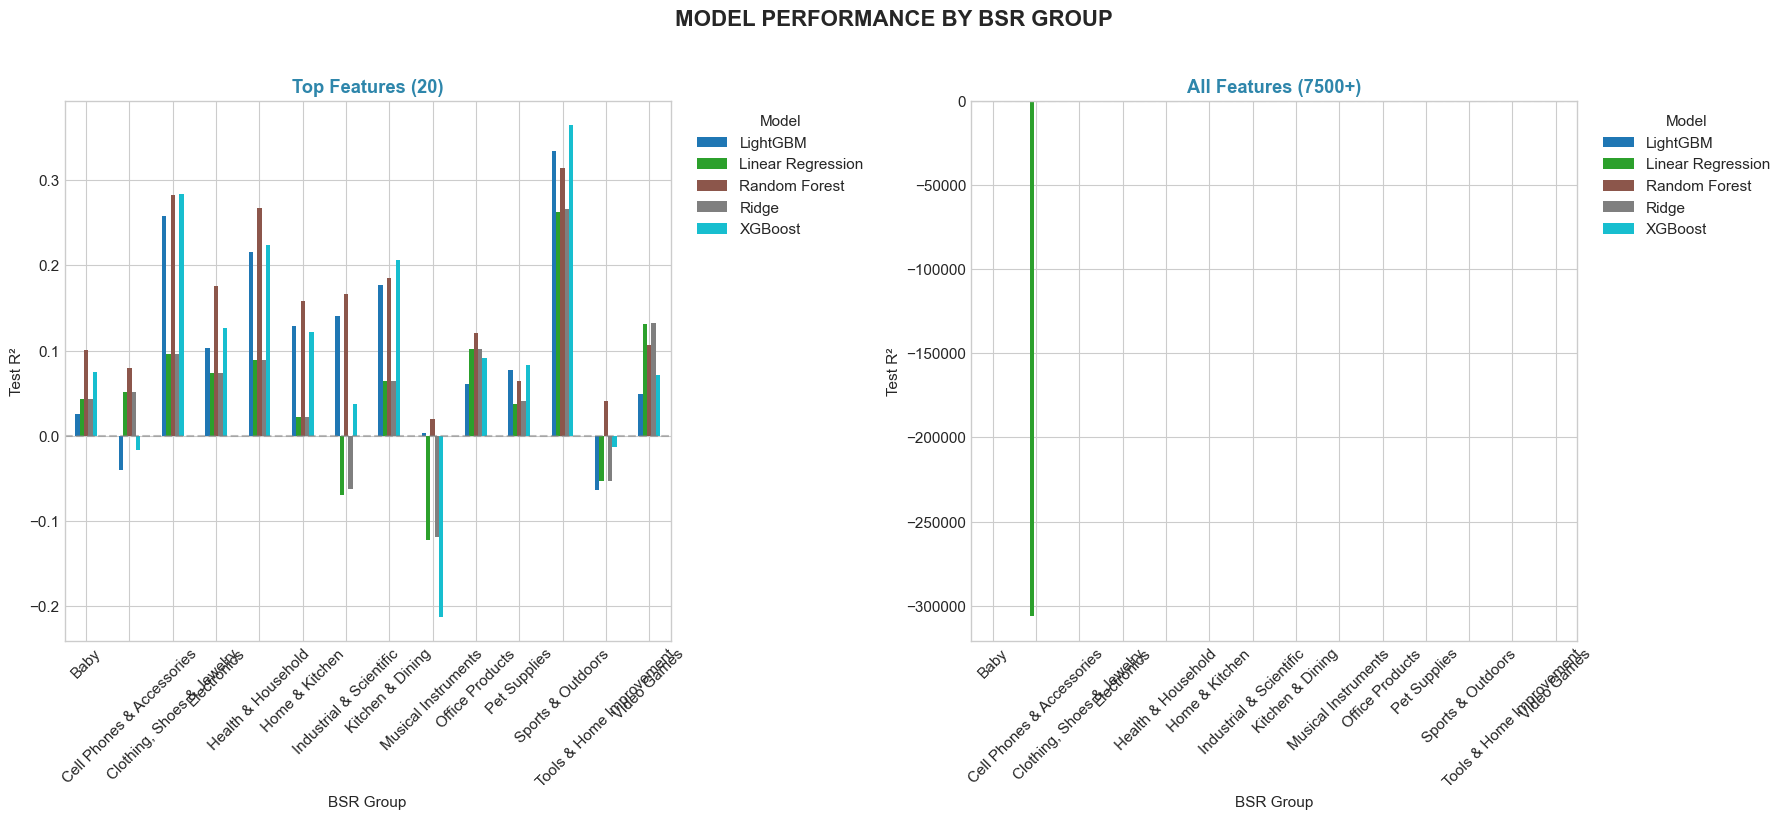

In [15]:
# =============================================================================
# 14. VISUALIZATION - R² BY BSR GROUP AND MODEL TYPE
# =============================================================================

# Truncate BSR group names for readability
summary_plot = summary_all.copy()
summary_plot['BSR_Group_Short'] = summary_plot['BSR_Group'].str[:40]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Top Features
ax1 = axes[0]
df_plot = summary_plot[summary_plot['Feature_Set'] == 'Top Features']
if len(df_plot) > 0:
    pivot = df_plot.pivot_table(values='Test_R2', index='BSR_Group_Short', columns='Model', aggfunc='first')
    pivot.plot(kind='bar', ax=ax1, colormap='tab10')
    ax1.set_title('Top Features (20)', fontweight='bold', color=MAIN_BSR_COLOR)
    ax1.set_ylabel('Test R²')
    ax1.set_xlabel('BSR Group')
    ax1.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax1.tick_params(axis='x', rotation=45)
    ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)

# All Features
ax2 = axes[1]
df_plot = summary_plot[summary_plot['Feature_Set'] == 'All Features']
if len(df_plot) > 0:
    pivot = df_plot.pivot_table(values='Test_R2', index='BSR_Group_Short', columns='Model', aggfunc='first')
    pivot.plot(kind='bar', ax=ax2, colormap='tab10')
    ax2.set_title('All Features (7500+)', fontweight='bold', color=MAIN_BSR_COLOR)
    ax2.set_ylabel('Test R²')
    ax2.set_xlabel('BSR Group')
    ax2.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax2.tick_params(axis='x', rotation=45)
    ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)

plt.suptitle('MODEL PERFORMANCE BY BSR GROUP', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

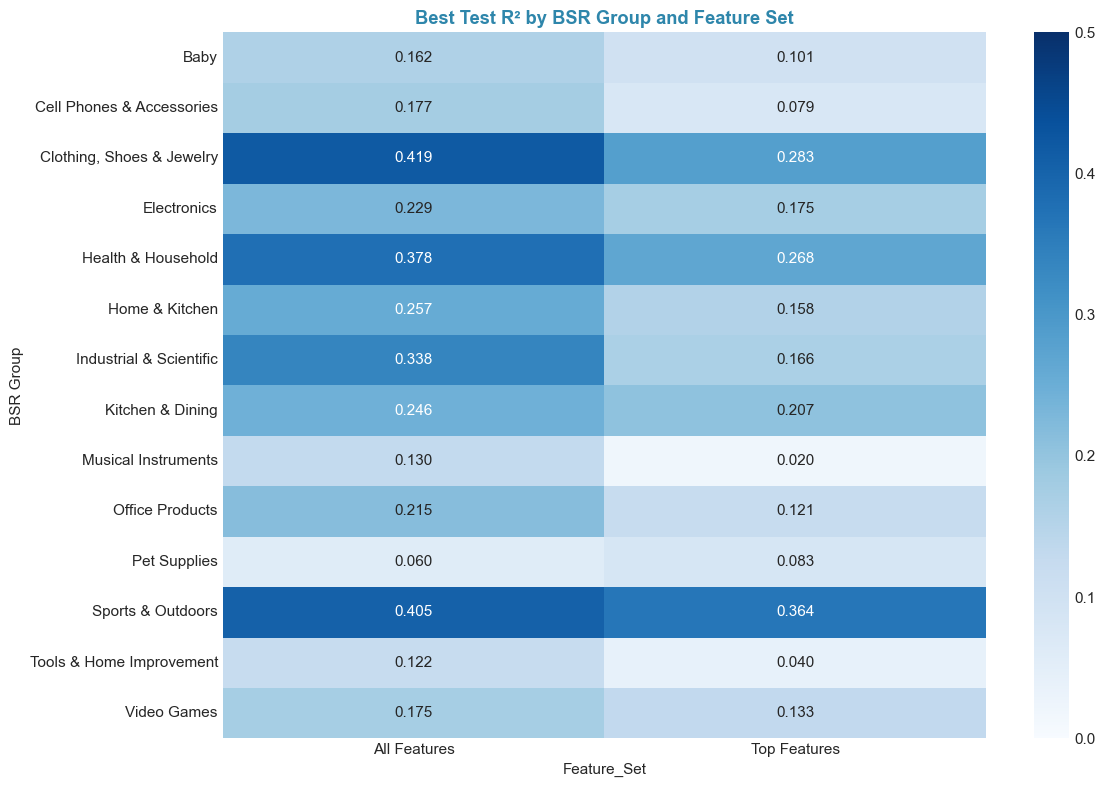

In [16]:
# =============================================================================
# 15. VISUALIZATION - BEST MODEL R² HEATMAP
# =============================================================================

# Get best R² per BSR group / feature_set combination
best_r2 = summary_all.groupby(['BSR_Group', 'Feature_Set'])['Test_R2'].max().reset_index()

# Truncate group names for display
best_r2['BSR_Group_Short'] = best_r2['BSR_Group'].str[:45]

fig, ax = plt.subplots(figsize=(12, max(8, len(best_r2['BSR_Group'].unique()) * 0.5)))

pivot = best_r2.pivot(
    index='BSR_Group_Short', columns='Feature_Set', values='Test_R2'
)
if len(pivot) > 0:
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='Blues', ax=ax, 
                vmin=0, vmax=max(0.5, pivot.max().max()))
    ax.set_title('Best Test R² by BSR Group and Feature Set', fontweight='bold', color=MAIN_BSR_COLOR)
    ax.set_ylabel('BSR Group')

plt.tight_layout()
plt.show()

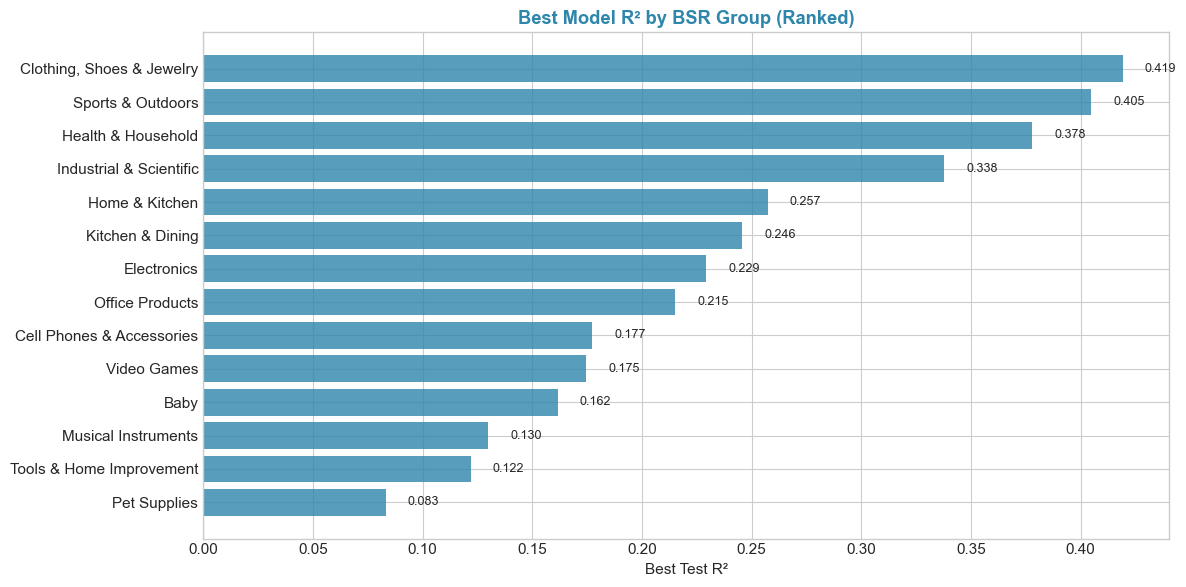

In [17]:
# =============================================================================
# 16. VISUALIZATION - BSR GROUP PERFORMANCE RANKING
# =============================================================================

# Get overall best model per BSR group (across all feature sets)
best_per_group = summary_all.groupby('BSR_Group')['Test_R2'].max().sort_values(ascending=True)

# Truncate names for display
best_per_group_display = best_per_group.copy()
best_per_group_display.index = [g[:50] for g in best_per_group.index]

fig, ax = plt.subplots(figsize=(12, max(6, len(best_per_group) * 0.4)))

bars = ax.barh(range(len(best_per_group_display)), best_per_group_display.values, color=MAIN_BSR_COLOR, alpha=0.8)
ax.set_yticks(range(len(best_per_group_display)))
ax.set_yticklabels(best_per_group_display.index)
ax.set_xlabel('Best Test R²')
ax.set_title('Best Model R² by BSR Group (Ranked)', fontweight='bold', color=MAIN_BSR_COLOR)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)

# Add value labels
for i, v in enumerate(best_per_group_display.values):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [18]:
# =============================================================================
# 17. FEATURE IMPORTANCE - BEST MODEL PER BSR GROUP
# =============================================================================

def get_best_model_with_importance(results_dict):
    """Get the best model that has feature_importances_ for each BSR group"""
    best_models = {}
    for group, group_results in results_dict.items():
        # Get models with feature importance capability
        models_with_fi = {}
        for name, metrics in group_results['results'].items():
            if hasattr(metrics['model'], 'feature_importances_'):
                models_with_fi[name] = metrics
        
        if models_with_fi:
            best_name = max(models_with_fi.keys(), key=lambda k: models_with_fi[k]['test_r2'])
            best_models[group] = {
                'model_name': best_name,
                'model': models_with_fi[best_name]['model'],
                'test_r2': models_with_fi[best_name]['test_r2'],
                'feature_names': group_results['data']['feature_names']
            }
    return best_models

# Get best models with feature importance for Main BSR (All Features)
best_models_main = get_best_model_with_importance(all_results['main_bsr']['all'])

print("Best models with feature importance per BSR Group (All Features):")
for group, info in best_models_main.items():
    print(f"  {group[:50]}: {info['model_name']} (R²={info['test_r2']:.4f})")

Best models with feature importance per BSR Group (All Features):
  Home & Kitchen: XGBoost (R²=0.2573)
  Health & Household: LightGBM (R²=0.3779)
  Office Products: XGBoost (R²=0.2152)
  Baby: LightGBM (R²=0.1617)
  Clothing, Shoes & Jewelry: LightGBM (R²=0.4191)
  Kitchen & Dining: LightGBM (R²=0.2457)
  Electronics: LightGBM (R²=0.2293)
  Cell Phones & Accessories: LightGBM (R²=0.1774)
  Tools & Home Improvement: LightGBM (R²=0.1220)
  Video Games: Random Forest (R²=0.1746)
  Pet Supplies: Random Forest (R²=0.0602)
  Sports & Outdoors: LightGBM (R²=0.4048)
  Industrial & Scientific: XGBoost (R²=0.3378)
  Musical Instruments: XGBoost (R²=0.1299)


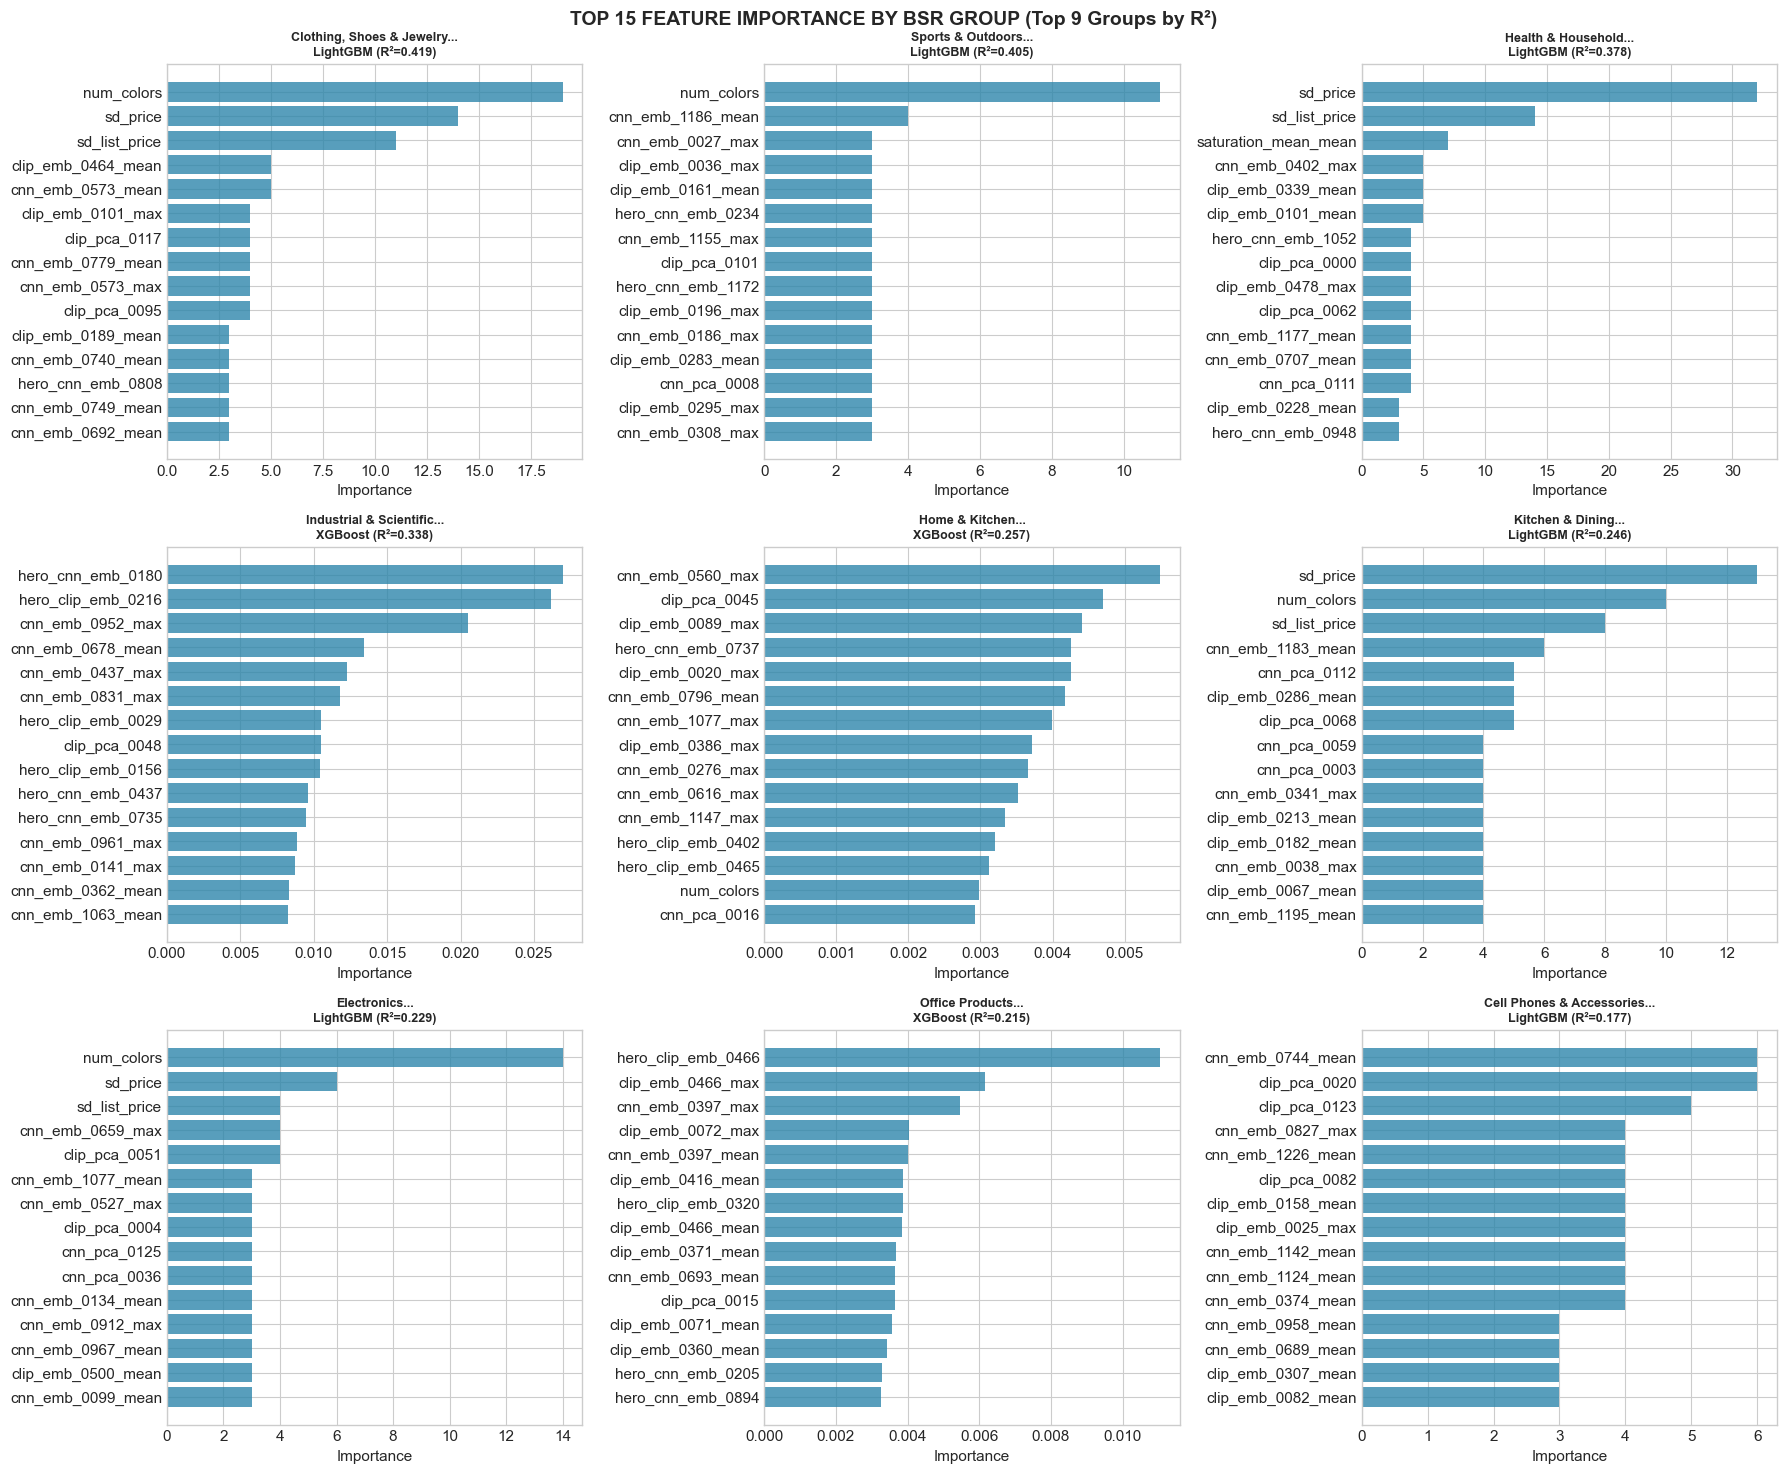

In [19]:
# =============================================================================
# 18. PLOT FEATURE IMPORTANCE BY BSR GROUP
# =============================================================================

n_groups = len(best_models_main)
if n_groups > 0:
    # Limit to top 9 groups for readability
    top_groups = dict(sorted(best_models_main.items(), key=lambda x: x[1]['test_r2'], reverse=True)[:9])
    
    n_plot = len(top_groups)
    cols = min(3, n_plot)
    rows = (n_plot + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 5*rows))
    if n_plot == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for idx, (group, info) in enumerate(top_groups.items()):
        ax = axes[idx]
        
        # Get feature importance
        feat_imp = pd.DataFrame({
            'feature': info['feature_names'],
            'importance': info['model'].feature_importances_
        }).sort_values('importance', ascending=False).head(15)
        
        ax.barh(range(len(feat_imp)), feat_imp['importance'], color=MAIN_BSR_COLOR, alpha=0.8)
        ax.set_yticks(range(len(feat_imp)))
        ax.set_yticklabels([f[:25] for f in feat_imp['feature']])
        ax.set_xlabel('Importance')
        ax.set_title(f'{group[:35]}...\n{info["model_name"]} (R²={info["test_r2"]:.3f})', fontsize=9, fontweight='bold')
        ax.invert_yaxis()
    
    # Hide unused axes
    for idx in range(len(top_groups), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('TOP 15 FEATURE IMPORTANCE BY BSR GROUP (Top 9 Groups by R²)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [20]:
# =============================================================================
# 19. MODEL COMPARISON TABLE - ALL BSR GROUPS
# =============================================================================

print("="*80)
print("COMPLETE MODEL COMPARISON TABLE")
print("="*80)

# Pivot for easy comparison
comparison = summary_all.pivot_table(
    values='Test_R2',
    index='BSR_Group',
    columns=['Feature_Set', 'Model'],
    aggfunc='first'
)

print("\nTest R² by BSR Group, Feature Set, and Model:")
print(comparison.round(4).to_string())

COMPLETE MODEL COMPARISON TABLE

Test R² by BSR Group, Feature Set, and Model:
Feature_Set               All Features                                                 Top Features                                                
Model                         LightGBM Linear Regression Random Forest   Ridge XGBoost     LightGBM Linear Regression Random Forest   Ridge XGBoost
BSR_Group                                                                                                                                          
Baby                            0.1617         -383.3237        0.1346 -2.2535  0.1245       0.0263            0.0437        0.1008  0.0437  0.0755
Cell Phones & Accessories       0.1774      -305906.5343        0.1251 -0.5064  0.1333      -0.0395            0.0518        0.0794  0.0511 -0.0169
Clothing, Shoes & Jewelry       0.4191          -67.1736        0.3083 -7.3439  0.3979       0.2577            0.0955        0.2833  0.0957  0.2834
Electronics                     0

In [21]:
# =============================================================================
# 20. SAVE RESULTS
# =============================================================================

# Save summary to CSV
summary_all.to_csv('bsr_group_baseline_models_comparison.csv', index=False)
print("Results saved to 'bsr_group_baseline_models_comparison.csv'")

# Display summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

print(f"\nTotal models trained: {len(summary_all)}")
print(f"BSR Groups with successful models: {summary_all['BSR_Group'].nunique()}")

print("\nAverage Test R² by Feature Set:")
print(summary_all.groupby('Feature_Set')['Test_R2'].mean().round(4).to_string())

print("\nBest overall model:")
best_row = summary_all.loc[summary_all['Test_R2'].idxmax()]
print(f"  {best_row['Model']} on '{best_row['BSR_Group'][:50]}' ({best_row['Feature_Set']}) - R²={best_row['Test_R2']:.4f}")

Results saved to 'bsr_group_baseline_models_comparison.csv'

SUMMARY STATISTICS

Total models trained: 140
BSR Groups with successful models: 14

Average Test R² by Feature Set:
Feature_Set
All Features   -4380.6065
Top Features       0.0925

Best overall model:
  LightGBM on 'Clothing, Shoes & Jewelry' (All Features) - R²=0.4191


In [22]:
# =============================================================================
# 21. FINAL SUMMARY
# =============================================================================

print("\n" + "="*80)
print("KEY FINDINGS - PER-BSR-GROUP BASELINE MODELING")
print("="*80)

print("""
This notebook trained baseline regression models for BSR rank prediction
within each main BSR group (with at least 100 products).

KEY OBSERVATIONS:

1. MODEL PERFORMANCE VARIES BY BSR GROUP:
   - Some BSR groups show stronger predictive signal from image features
   - Performance differences may reflect group-specific image importance
   - Groups with better R² may have more visually-driven purchasing

2. FEATURE SET COMPARISON:
   - Top Features (20): Faster training, potentially less overfitting
   - All Features (7500+): May capture more nuanced patterns but slower

3. LINEAR VS NON-LINEAR:
   - Non-linear models (RF, XGBoost, LightGBM) generally outperform linear
   - Tree-based models can capture complex feature interactions

4. GROUP SIZE CONSIDERATION:
   - Larger groups (more products) provide more training data
   - Groups with minimum 100 products were included

RECOMMENDATIONS:
- Consider BSR-group-specific models for production
- Groups with low R² may need additional features beyond images
- Hyperparameter tuning could improve performance further
""")

print("\nNotebook complete!")


KEY FINDINGS - PER-BSR-GROUP BASELINE MODELING

This notebook trained baseline regression models for BSR rank prediction
within each main BSR group (with at least 100 products).

KEY OBSERVATIONS:

1. MODEL PERFORMANCE VARIES BY BSR GROUP:
   - Some BSR groups show stronger predictive signal from image features
   - Performance differences may reflect group-specific image importance
   - Groups with better R² may have more visually-driven purchasing

2. FEATURE SET COMPARISON:
   - Top Features (20): Faster training, potentially less overfitting
   - All Features (7500+): May capture more nuanced patterns but slower

3. LINEAR VS NON-LINEAR:
   - Non-linear models (RF, XGBoost, LightGBM) generally outperform linear
   - Tree-based models can capture complex feature interactions

4. GROUP SIZE CONSIDERATION:
   - Larger groups (more products) provide more training data
   - Groups with minimum 100 products were included

RECOMMENDATIONS:
- Consider BSR-group-specific models for product